In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [69]:
df = pd.read_csv('../data/Classification_smoke_detectors_filtered.csv')

In [70]:
target = 'Fire Alarm'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777, stratify=y)

In [71]:
num_classes = y.nunique()
num_classes

2

Классификация бинарная

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

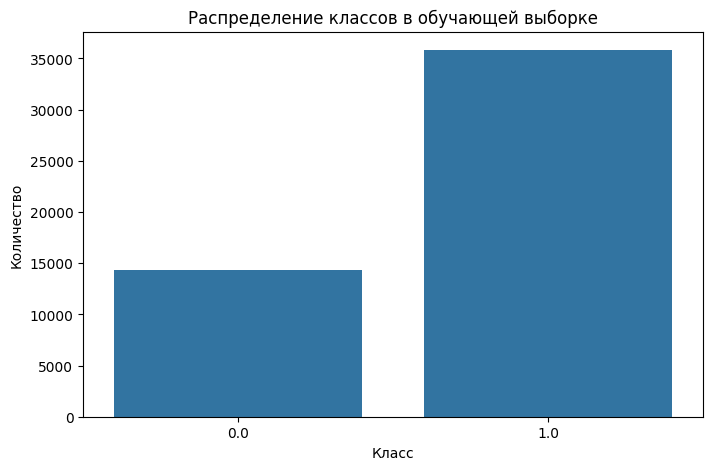

In [73]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title('Распределение классов в обучающей выборке')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

In [74]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=777)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"До балансировки: {y_train.value_counts().to_dict()}")
print(f"После балансировки: {y_train_balanced.value_counts().to_dict()}")

До балансировки: {1.0: 35806, 0.0: 14298}
После балансировки: {1.0: 35806, 0.0: 35806}


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "Naive Bayes": Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
    "SVM (RBF Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='rbf'))]),
    "SVM (Sigmoid Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='sigmoid'))]),
    "SVM (Polynomial Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='poly', degree=3))]),
    "SVM (Linear Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='linear'))]),
}

In [76]:
import joblib
import os

preloadModel = True

for name, model in models.items():
    model_path = f'../models/{name}.pkl'
    if preloadModel and os.path.exists(model_path):
        loaded_model = joblib.load(f'../models/{name}.pkl')
        y_pred = loaded_model.predict(X_test)
        print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")
        continue

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    joblib.dump(model, f'../models/{name}.pkl')
    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.9835
KNN: 0.9995
Naive Bayes: 0.8202
SVM (RBF Kernel): 0.9995
SVM (Sigmoid Kernel): 0.8023
SVM (Polynomial Kernel): 0.9995
SVM (Linear Kernel): 0.9927


In [77]:
import optuna
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=777)

In [78]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(models["Logistic Regression"], param_grid_lr, cv=kf, scoring='accuracy')

grid_lr.fit(X_train, y_train)
y_pred = grid_lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.987226568737027

In [81]:
param_dist_knn = {
    'clf__n_neighbors': range(1, 21),
    'clf__weights': ['uniform', 'distance']
}

random_knn = RandomizedSearchCV(models["KNN"], param_dist_knn, n_iter=10, cv=kf, scoring='accuracy', random_state=777)

random_knn.fit(X_train, y_train)
y_pred = random_knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.9995209963276385

In [82]:
def objective_nb(trial, X, y):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-7, log=True)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", GaussianNB(var_smoothing=var_smoothing))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective_nb(trial, X, y), n_trials=5)
print(study.best_value)

[I 2026-04-02 09:50:12,893] A new study created in memory with name: no-name-09033562-9b0e-4b0f-a1ae-4a6eeb1d1f1a
[I 2026-04-02 09:50:13,001] Trial 0 finished with value: 0.8303528660386397 and parameters: {'var_smoothing': 3.0585221921181966e-08}. Best is trial 0 with value: 0.8303528660386397.
[I 2026-04-02 09:50:13,106] Trial 1 finished with value: 0.8303528660386397 and parameters: {'var_smoothing': 1.337648212124812e-08}. Best is trial 0 with value: 0.8303528660386397.
[I 2026-04-02 09:50:13,218] Trial 2 finished with value: 0.8303528660386397 and parameters: {'var_smoothing': 6.043331668805692e-09}. Best is trial 0 with value: 0.8303528660386397.
[I 2026-04-02 09:50:13,328] Trial 3 finished with value: 0.8303528660386397 and parameters: {'var_smoothing': 1.5748771052181237e-08}. Best is trial 0 with value: 0.8303528660386397.
[I 2026-04-02 09:50:13,436] Trial 4 finished with value: 0.8303528660386397 and parameters: {'var_smoothing': 1.0478886014752876e-10}. Best is trial 0 with 

0.8303528660386397


In [83]:
def objective_svm_rbf(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='rbf', C=c, gamma=gamma))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective_svm_rbf(trial, X, y), n_trials=5)
print(study.best_value)

[I 2026-04-02 09:50:21,560] A new study created in memory with name: no-name-e3cbfaa6-fa02-49b5-aa9e-d6f04bda4b63
[I 2026-04-02 09:50:34,324] Trial 0 finished with value: 0.9993134280696152 and parameters: {'C': 0.46027146313970196, 'gamma': 'scale'}. Best is trial 0 with value: 0.9993134280696152.
[I 2026-04-02 09:50:46,820] Trial 1 finished with value: 0.9993134280696152 and parameters: {'C': 0.4691417019157095, 'gamma': 'scale'}. Best is trial 0 with value: 0.9993134280696152.
[I 2026-04-02 09:50:52,498] Trial 2 finished with value: 0.9996806642184257 and parameters: {'C': 3.4221933208106927, 'gamma': 'scale'}. Best is trial 2 with value: 0.9996806642184257.
[I 2026-04-02 09:51:04,534] Trial 3 finished with value: 0.9993134280696152 and parameters: {'C': 0.5092504073580897, 'gamma': 'auto'}. Best is trial 2 with value: 0.9996806642184257.
[I 2026-04-02 09:51:22,040] Trial 4 finished with value: 0.9991856937569855 and parameters: {'C': 0.21532939773731435, 'gamma': 'auto'}. Best is t

0.9996806642184257


In [86]:
def objective_svm_sigmoid(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='sigmoid', C=c, coef0=coef0))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective_svm_sigmoid(trial, X, y), n_trials=5)
print(study.best_value)

[I 2026-04-02 09:55:23,009] A new study created in memory with name: no-name-3e252c9c-1a6d-4acf-a303-25386acb7fc5
[I 2026-04-02 09:56:23,225] Trial 0 finished with value: 0.8005588376177549 and parameters: {'C': 0.13818910458784556, 'coef0': 0.4150950658847278}. Best is trial 0 with value: 0.8005588376177549.
[I 2026-04-02 09:57:21,870] Trial 1 finished with value: 0.8062589813188568 and parameters: {'C': 5.332439100076637, 'coef0': 0.13279539355480385}. Best is trial 1 with value: 0.8062589813188568.
[I 2026-04-02 09:58:22,687] Trial 2 finished with value: 0.8054127414976847 and parameters: {'C': 4.824349139677059, 'coef0': 0.17200794427891763}. Best is trial 1 with value: 0.8062589813188568.
[I 2026-04-02 09:59:22,598] Trial 3 finished with value: 0.8056682101229443 and parameters: {'C': 3.2500187568418366, 'coef0': 0.184394886176371}. Best is trial 1 with value: 0.8062589813188568.
[W 2026-04-02 10:00:06,861] Trial 4 failed with parameters: {'C': 5.096922290070442, 'coef0': 0.195362

KeyboardInterrupt: 

In [ ]:
def objective_svm_poly(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    degree = trial.suggest_int('degree', 2, 5)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='poly', C=c, degree=degree))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective_svm_poly(trial, X, y), n_trials=5)
print(study.best_value)

In [ ]:
def objective_svm_linear(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='linear', C=c))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study = optuna.create_study(direction="maximize")
study.optimize(lambda trial: objective_svm_poly(trial, X, y), n_trials=5)
print(study.best_value)